<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/supervised/es5_CNN_classification_pytorch_start.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this lab you will do the following steps in order:

1. Load the SimplicityDB training and test datasets using
   ``torchvision``
2. Define a Convolution Neural Network
3. Define a loss function and optimizer
4. Train the network on the training data
5. Test the network on the test data


Import all libraries

In [17]:
import torch
import torchvision
import torchvision.transforms as transforms
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Use GPU if available

In [2]:
train_on_gpu = torch.cuda.is_available()
if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')
device = torch.device("cuda:0" if train_on_gpu else "cpu")
print(device)

CUDA is available!  Training on GPU ...
cuda:0


In [3]:
# load dataset form drive
drive.flush_and_unmount()
drive.mount("/content/drive")

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
# unzip the dataset
!unzip /content/drive/MyDrive/Supervised/CNN/SimplicityDB.zip

# LAB

1. Load the SimplicityDB training and test datasets using
   ``torchvision``
   

We first need to extract the dataset from the compressed .zip file.

Torchvision will load the images as PIL images: we need to define the transformations to perform over the loaded images in order to obtain a torch Tensors.
After that we can use the [ImageFolder](https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html) class to istantiate a dataset and then initialize the [Dataloader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).



In [9]:
# Define data transformation pipeline
glb_mean = [0.485, 0.456, 0.406]
glb_std = [0.229, 0.224, 0.225]
transformer_pipeline = transforms.Compose([
    transforms.Resize([500, 500]),
    # transforms.RandomResizedCrop(size=(224, 224), antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])

# Load data useing ImageFolder | training
trainset = torchvision.datasets.ImageFolder('SimplicityDB/train', transformer_pipeline)

# Create data loader for training data with batch size 4 and shuffling
trainloader = torch.utils.data.DataLoader(trainset, 32, True, drop_last=True, num_workers=2)

# Load data useing ImageFolder | test
testset = torchvision.datasets.ImageFolder('SimplicityDB/test', transformer_pipeline)


# Create data loader for testing data with batch size 1 and shuffling
testloader = torch.utils.data.DataLoader(testset, 32, False, drop_last=False)


classes = ['People', 'Beaches', 'Buildings', 'Buses', 'Dinosarus', 'Elephants', 'Flowers', 'Horses', "Mountains", "Food"]


In [10]:
trainloader.dataset.classes

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Let's take a look at some of the training images.

[imshow function](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html#matplotlib-pyplot-imshow)


Train loader:
21
{'People': 70, 'Beaches': 70, 'Buildings': 70, 'Buses': 70, 'Dinosarus': 70, 'Elephants': 70, 'Flowers': 70, 'Horses': 70, 'Mountains': 70, 'Food': 70}
torch.Size([32, 3, 500, 500])
Flowers Elephants Elephants Beaches

Test loader:
10
{'People': 30, 'Beaches': 30, 'Buildings': 30, 'Buses': 30, 'Dinosarus': 30, 'Elephants': 30, 'Flowers': 30, 'Horses': 30, 'Mountains': 30, 'Food': 30}


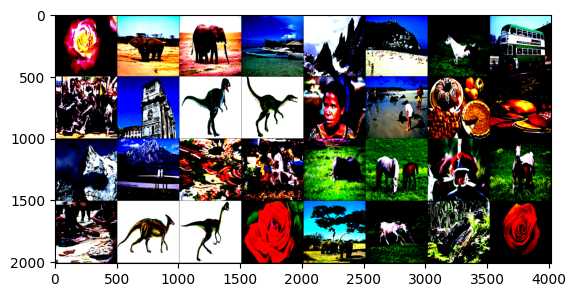

In [18]:
# Function to display an image
def imshow(image):

    image= image.clamp(0, 1)

    # Convert the tensor to a NumPy array
    npimg = image.numpy()

    # Plot the image using matplotlib
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Transpose for correct display


# ------------------ Train Loader Section ------------------

print("Train loader:")

# Count the frequency of each class in the training set
stat = dict(Counter(trainset.targets))

# Create a new dictionary with class names as keys
new_stat = stat.copy()
for k in stat.keys():
    new_stat[classes[k]] = stat[k]
    del new_stat[k]

# Print the length of the train loader (number of batches)
print(len(trainloader))

# Print the class distribution in the training set
print(new_stat)

# Get a batch of random training images and their labels
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Print the shape of the image tensor (batch_size, channels, height, width)
print(images.shape)

# Display the images using the imshow function
imshow(torchvision.utils.make_grid(images))

# Print the labels of the images
print(' '.join('%s' % classes[labels[j]] for j in range(4)))  # Print labels for 4 images

# ------------------ Test Loader Section ------------------

print("\nTest loader:")

# Similar steps for the test loader
stat = dict(Counter(testset.targets))
new_stat = stat.copy()
for k in stat.keys():
    new_stat[classes[k]] = stat[k]
    del new_stat[k]

print(len(testloader))
print(new_stat)


2. Define a Convolution Neural Network.
[network layers](https://pytorch.org/docs/stable/nn.html#convolution-layers)

In [19]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):

    def __init__(self, num_class):
        super(Net, self).__init__()  # Call the superclass constructor

        # TODO
        self.conv1 = nn.Conv2d(3, 8, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 16, 5)
        self.fc1 = nn.Linear(16*122*122, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_class)

    def forward(self, x):

        # TODO
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net(len(classes))
net.to(device)

Net(
  (conv1): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=238144, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

3. Define a loss function and optimizer

Let's use a Classification [Cross-Entropy](https://pytorch.org/docs/stable/nn.html#loss-functions) loss and [SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD) with momentum.



In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=net.parameters(), lr=0.001, momentum=0.9)

4. Train the network on the training data


We simply have to loop over our data iterator, and feed the inputs to the
network and optimize.



In [ ]:
num_print_intervals = 4  # Number of times to print statistics

num_print_intervals+=1
print_interval = int(len(trainloader) / num_print_intervals)

# Loop over the dataset multiple times (2 epochs in this case)
for epoch in range(2):
  running_loss = []

  # Iterate over the training data loader
  for i, data in enumerate(trainloader, 0):

    # TODO
    inputs, labels = data
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()# remove all the gradient has been added
    outputs = net(inputs) # directly calling forward function
    loss = criterion(outputs, labels)
    loss.backward()
    # at this point we computed the gradient
    optimizer.step() # update the parameter
    running_loss.append(loss.item())
    if i>0 and i%print_interval ==0:

      print(f'[{epoch+1}, {i+1}] loss: {np.mean(running_loss)}')
      running_loss = []

# Training complete
print('Finished Training')


5. Test the network on the test data


We have trained the network for 2 passes over the training dataset.
But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

In [ ]:
# Initialize variables to track accuracy
correct = 0
total = 0

# Disable gradient calculation for better performance during evaluation
with torch.no_grad():
    # Loop over the test loader
    for data in testloader:
        # Get the image and label from the current batch
        image, label = data

        # Move the image data to the specified device (CPU or GPU)
        image = image.to(device)

        # Get the network's prediction for the image
        output = net(image)
        # smax = torch.nn.Softmax(dim=1)(output.cpu())

        # Find the class with the highest probability
        _, predicted = torch.max(output.cpu(), 1)  # Equivalent to pred = torch.argmax(output.cpu(), dim=1)

        # Update total number of test images
        total += label.size(0)  # label.size(0) gives the batch size

        # Count correct predictions
        correct += (predicted == label).sum().item()  # Count true positives
        print(f'predicted: {predicted}')


# Calculate and print accuracy
print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))


# **!HOMEWORK!**

This homework assignment asks you to performs 2 tasks:

1. Analyze Results with Different Network Parameters:

This involves training the network with various configurations of network parameters and analyzing the impact on performance. Here's a step-by-step approach:

**Choose Network Parameters:**

Select the network parameters you want to experiment with. Common choices include:

- Number of layers: You can try increasing or decreasing the number of layers in your chosen network architecture (e.g., convolutional layers in a CNN).
- Number of filters in convolutional layers: This affects the complexity of features extracted from the data.



**Analyze Results:**

Compare the performance of the network across different parameter configurations:

How accuracy/loss changes with different parameter values.

2. Show and Explain Errors of the Best Network:

Once you identify the **best performing network configuration** (based on metrics like accuracy or loss), analyze its errors.
For example you can generate a confusion matrix. This matrix visualizes how often the network predicted each class correctly or incorrectly.

Useful resources:
*   [network layers](https://pytorch.org/docs/stable/nn.html#convolution-layers)
*   [activation function](https://pytorch.org/docs/stable/nn.html#convolution-layers)
*   [loss functions](https://pytorch.org/docs/stable/nn.html#convolution-layers)





In [5]:
# Add Augmentation pipeline
glb_mean = [0.485, 0.456, 0.406]
glb_std = [0.229, 0.224, 0.225]
transform_pipline = transforms.Compose([
    transforms.Resize(size=(300, 300)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=glb_mean, std=glb_std),
])
# get all the training and testing Image folder
train_data = torchvision.datasets.ImageFolder('SimplicityDB/train', transform=transform_pipline)
test_data = torchvision.datasets.ImageFolder('SimplicityDB/test', transform=transform_pipline)

# load the training & testing datasets
train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=16, shuffle=True, drop_last=False)

classes = ['People', 'Beaches', 'Buildings', 'Buses',
           'Dinosarus', 'Elephants', 'Flowers', 'Horses', "Mountains", "Food"]


In [6]:
train_data.classes

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [34]:
imgs, labels = next(iter(train_loader))

imgs.shape, labels.shape

(torch.Size([16, 3, 300, 300]), torch.Size([16]))

In [6]:
class NeuralNetwork(nn.Module):
  def __init__(self, num_class):
    super(NeuralNetwork, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, 3, 1)
    self.conv2 = nn.Conv2d(32, 64, 3, 1)
    self.conv3 = nn.Conv2d(64, 128, 3, 1)
    self.conv4 = nn.Conv2d(128, 224, 3, 1)

    self.pool = nn.MaxPool2d(2, 2)
    self.gap = nn.AdaptiveAvgPool2d((1, 1)) # force the output to fix size

    self.fc1 = nn.Linear(224, 128)
    self.fc2 = nn.Linear(128, num_class)
  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = self.pool(F.relu(self.conv3(x)))
    x = self.pool(F.relu(self.conv4(x)))
    # print(f'x4: {x.shape}')
    x = self.gap(x)
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = self.fc2(x)
    return x

net = NeuralNetwork(len(train_data.classes)).to(device)
net

NeuralNetwork(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(128, 224, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=224, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
dumy_data = torch.randn(2, 3, 300, 300).to(device)
pred = net(dumy_data)
pred

In [30]:
# define the optimizer and loss function
optimizer = torch.optim.Adam(params=net.parameters(), lr=0.0005)
loss_fun = torch.nn.CrossEntropyLoss()

In [38]:
def train(data_loader, loss_fun, optimizer):
  number_of_batches = len(data_loader)
  training_loss = 0
  net.train()
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    optimizer.zero_grad()
    output = net(X)
    loss = loss_fun(output, y)
    loss.backward()
    optimizer.step()

    training_loss += loss.item()
    if (batch+1 == number_of_batches):
      print(f'Batch {batch+1}/{number_of_batches} | Loss: {loss.item():.4f}')
  return training_loss/number_of_batches

In [7]:
# Validate the model
def val_model(data_loader, loss_fun):
  val_loss = 0
  net.eval()
  with torch.no_grad(): # disable the grade calculation
    for data in data_loader:
      X, y = data
      X, y = X.to(device), y.to(device)

      output = net(X)

      loss = loss_fun(output, y)
      val_loss += loss.item()
  return val_loss/len(data_loader)

In [39]:
def train_and_validate(net, epoch=5):
  history = {'tr_loss': [], 'val_loss': []}
  best_val = float('inf')
  patience = 3
  counter = 0
  best_epoch = 0
  for i in range(epoch):
    print(f"Epoch {i}: ")
    tr_loss = train(train_loader, loss_fun, optimizer=optimizer)
    history['tr_loss'].append(tr_loss)
    avg_loss = val_model(test_loader, loss_fun)

    history['val_loss'].append(avg_loss)
    print(f"Validation loss: {avg_loss}")

    if avg_loss < best_val:
        best_val = avg_loss
        counter = 0
        best_epoch = i
        torch.save(net.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping!")
        break
  print(f"Best model at epoch {best_epoch}")
  return history

<Axes: >

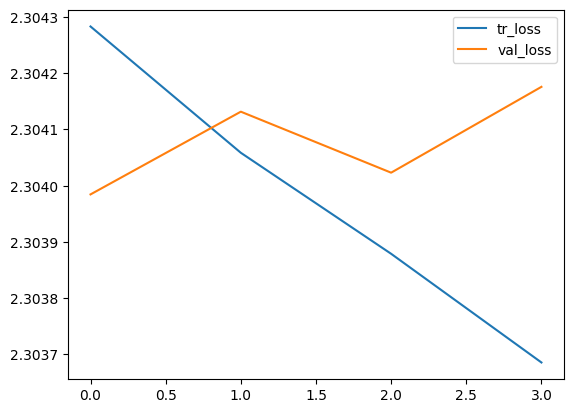

In [77]:
history = train_and_validate(net, 5)
# plot the loss curve
pd.DataFrame(history).plot()

In this time model learn over 5 epochs with the following parameters
1. 4 conve layer with `kernalsize=3, strid=1` & and a downsampalling layer of `kernal_size=2, strid=2`
2. Adam optimizer with `learning_rate=0.0005`
3. According to the loss curve the model seems
- **Not learning at all just random guessing**
- **Weights are not improving predictions**
- **Training is basically stuck from the start**

 The reason might be:
  * Learning rate might be too small
  * Model is not normalized seems more plain
  * **update the weights** I forgot to add `optimizer.step()`

In [40]:
class NeuralNetwork(nn.Module):
  def __init__(self, num_class):
    super(NeuralNetwork, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, 3, 1)
    self.conv2 = nn.Conv2d(32, 64, 3, 1)
    self.conv3 = nn.Conv2d(64, 128, 3, 1)
    self.conv4 = nn.Conv2d(128, 224, 3, 1)

    self.bn1 = nn.BatchNorm2d(32)
    self.bn2 = nn.BatchNorm2d(64)
    self.bn3 = nn.BatchNorm2d(128)
    self.bn4 = nn.BatchNorm2d(224)


    self.pool = nn.MaxPool2d(2, 2)
    self.gap = nn.AdaptiveAvgPool2d((1, 1)) # force the output to fix size
    self.dropout = nn.Dropout(0.5)

    self.fc1 = nn.Linear(224, 128)
    self.fc2 = nn.Linear(128, num_class)
  def forward(self, x):
    x = self.pool(F.relu(self.bn1(self.conv1(x))))
    x = self.pool(F.relu(self.bn2(self.conv2(x))))
    x = self.pool(F.relu(self.bn3(self.conv3(x))))
    x = self.pool(F.relu(self.bn4(self.conv4(x))))
    # print(f'x4: {x.shape}')
    x = self.gap(x)
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = self.dropout(x) # <-- reduces overfitting
    x = self.fc2(x)
    return x

net = NeuralNetwork(len(train_data.classes)).to(device)
net

NeuralNetwork(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(128, 224, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(224, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=224, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [41]:
# define the optimizer and loss function
optimizer = torch.optim.Adam(params=net.parameters(), lr=0.001)
loss_fun = torch.nn.CrossEntropyLoss()

In [ ]:
history = train_and_validate(net, 5)

<Axes: >

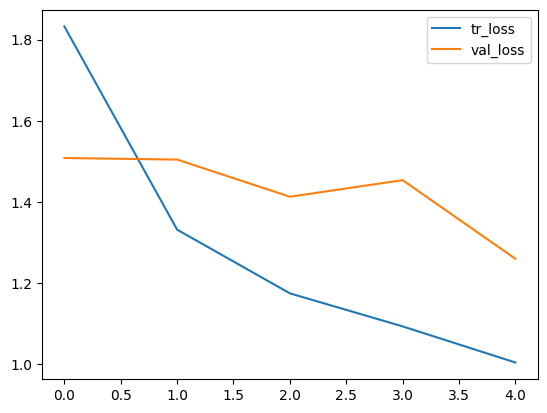

In [12]:
pd.DataFrame(history).plot()

In this experiment, the model was trained for 5 epochs using:

* 4 convolutional layers (`kernel_size=3`, `stride=1`, **padding=1**) with MaxPooling
* **Batch Normalization** after each convolution
* Global Average Pooling before fully connected layers
* Added dropout to reduce imediate overfittin
* Adam optimizer with **learning rate = 0.001**
* Correct weight update using `optimizer.step()`
* Training and validation loss **decrease over epochs**
* Model is **learning properly** (no longer random)


Previously, the model failed due to:

* Missing weight updates
* Lack of normalization

After fixing these, the model shows **stable learning**, with training longer or updating learning rate could improve performance further.



Epoch 0: 
Batch 43/43 | Loss: 1.6848
Validation loss: 1.2482963518092507
Epoch 1: 
Batch 43/43 | Loss: 1.0020
Validation loss: 1.3004255859475387
Epoch 2: 
Batch 43/43 | Loss: 1.1406
Validation loss: 1.1266988515853882
Epoch 3: 
Batch 43/43 | Loss: 0.8301
Validation loss: 0.9012427910378105
Epoch 4: 
Batch 43/43 | Loss: 1.0011
Validation loss: 0.7951965645739907
Epoch 5: 
Batch 43/43 | Loss: 0.6161
Validation loss: 0.8421246660383124
Epoch 6: 
Batch 43/43 | Loss: 0.3410
Validation loss: 0.8309079110622406
Epoch 7: 
Batch 43/43 | Loss: 0.4473
Validation loss: 0.7296798480184454
Epoch 8: 
Batch 43/43 | Loss: 0.4796
Validation loss: 0.7673420545301939
Epoch 9: 
Batch 43/43 | Loss: 0.6265
Validation loss: 0.8373465365485141
Epoch 10: 
Batch 43/43 | Loss: 1.6762
Validation loss: 0.5633246232020227
Epoch 11: 
Batch 43/43 | Loss: 0.4320
Validation loss: 0.6657948744924445
Epoch 12: 
Batch 43/43 | Loss: 0.2583
Validation loss: 0.5555846651918009
Epoch 13: 
Batch 43/43 | Loss: 0.8594
Validation

<Axes: >

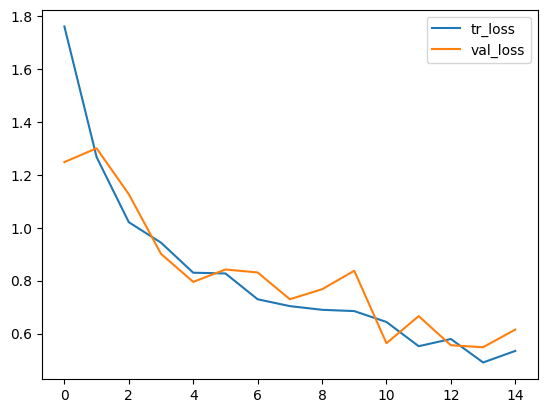

In [42]:
history = train_and_validate(net, 15)
pd.DataFrame(history).plot()

In [32]:
def plot_confusion_matrix(model, data_loader, device, class_names):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for X, y in data_loader:
            X = X.to(device)
            outputs = model(X)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y.numpy())

    # Convert to numpy
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)

    # Plot (super clean)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation=45)

    plt.title("Confusion Matrix")
    plt.show()

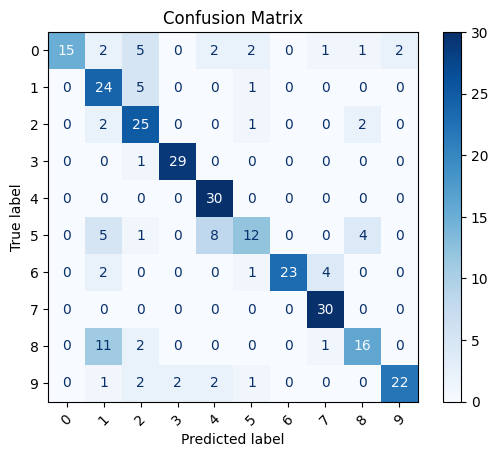

In [33]:
plot_confusion_matrix(net, test_loader, device, train_data.classes)